In [1]:
import pandas as pd
from scipy import stats
from scipy.stats import sem, skew, kurtosis
import seaborn as sns

import matplotlib.pyplot as plt


In [2]:
sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv('../data/output.csv')
df.head()

,row_index,benchmark,backend,architecture,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count
0,0,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,55833101.0,ns,70717
1,1,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,110493393.0,ns,141434
2,2,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,165340431.0,ns,212151
3,3,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,221207496.0,ns,282868
4,4,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,271881369.0,ns,353585


In [4]:
df['iteration_time'] = df['sample_measured_value'] / df['iteration_count']
df.head()

,row_index,benchmark,backend,architecture,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count,iteration_time
0,0,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,55833101.0,ns,70717,789.528699
1,1,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,110493393.0,ns,141434,781.236428
2,2,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,165340431.0,ns,212151,779.352588
3,3,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,221207496.0,ns,282868,782.016686
4,4,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,271881369.0,ns,353585,768.927893


In [5]:
UNIT_TO_SECONDS = {
    'ns': 1e-9,
    'us': 1e-6,
    'µs': 1e-6,
    'ms': 1e-3,
    's': 1.0,
}

df['throughput [elem/s]'] = (1 / (df['iteration_time'] * df['unit'].map(UNIT_TO_SECONDS))) * df['throughput_num']
df.head()

,row_index,benchmark,backend,architecture,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count,iteration_time,throughput [elem/s]
0,0,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,55833101.0,ns,70717,789.528699,3.242441e+08
1,1,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,110493393.0,ns,141434,781.236428,3.276857e+08
2,2,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,165340431.0,ns,212151,779.352588,3.284778e+08
3,3,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,221207496.0,ns,282868,782.016686,3.273587e+08
4,4,engine,avx2,x86_64,encrypt,32_64,1.0,256,elements,271881369.0,ns,353585,768.927893,3.329311e+08


In [6]:
GROUP_KEYS = ['benchmark', 'backend', 'architecture', 'function', 'version', 'suffix']


def benchmark_stats(group, col='throughput [elem/s]'):
    x = group[col]
    return pd.Series({
        # Położenie
        'mean': x.mean(),
        'median': x.median(),
        'mode': x.mode().iloc[0] if not x.mode().empty else float('nan'),
        'trimmed_mean': stats.trim_mean(x, 0.1),

        # Rozrzut
        'std': x.std(),
        'var': x.var(),
        'sem': sem(x),
        'cv': x.std() / x.mean(),
        'iqr': x.quantile(0.75) - x.quantile(0.25),

        # Percentyle
        'p5': x.quantile(0.05),
        'p25': x.quantile(0.25),
        'p75': x.quantile(0.75),
        'p95': x.quantile(0.95),
        'min': x.min(),
        'max': x.max(),

        # Kształt rozkładu
        'skewness': skew(x),
        'kurtosis': kurtosis(x),
    })


df_stats = df.groupby(GROUP_KEYS, dropna=False).apply(benchmark_stats).reset_index()
df_stats.head()

,benchmark,backend,architecture,function,version,suffix,mean,median,mode,trimmed_mean,...,cv,iqr,p5,p25,p75,p95,min,max,skewness,kurtosis
0,engine,avx2,x86_64,decrypt,128_128,1.0,5.126751e+07,5.136619e+07,5.037280e+07,5.136084e+07,...,0.006161,44428.239160,5.079235e+07,5.133966e+07,5.138409e+07,5.140542e+07,5.037280e+07,5.141558e+07,-2.619524,4.962740
1,engine,avx2,x86_64,decrypt,128_128,2.0,5.135678e+07,5.146117e+07,5.046915e+07,5.144608e+07,...,0.006241,87015.316973,5.083114e+07,5.141911e+07,5.150613e+07,5.152339e+07,5.046915e+07,5.152999e+07,-2.423950,4.294950
2,engine,avx2,x86_64,decrypt,128_128,3.0,5.119120e+07,5.119629e+07,5.107194e+07,5.119864e+07,...,0.001058,41361.467312,5.109817e+07,5.118632e+07,5.122768e+07,5.124611e+07,5.107194e+07,5.125098e+07,-1.109586,0.406149
3,engine,avx2,x86_64,decrypt,128_192,1.0,5.076083e+07,5.094025e+07,4.945371e+07,5.089773e+07,...,0.009231,118712.763984,5.000262e+07,5.084730e+07,5.096602e+07,5.097158e+07,4.945371e+07,5.097282e+07,-2.486530,4.502136
4,engine,avx2,x86_64,decrypt,128_192,2.0,5.086562e+07,5.096305e+07,5.022158e+07,5.092644e+07,...,0.004769,152850.617661,5.046175e+07,5.084282e+07,5.099567e+07,5.102070e+07,5.022158e+07,5.102305e+07,-2.093525,3.205730


In [7]:
parts = df_stats['version'].str.extract(r'^(?P<block_bits>\d+)_(?P<key_bits>\d+)$').astype(int)

df_stats = df_stats.join(parts)
df_stats['word_bits'] = df_stats['block_bits'] // 2
df_stats['key_words'] = df_stats['key_bits'] // df_stats['word_bits']

SPECK_ROUNDS = {
    (32, 64): 22,
    (48, 72): 22,
    (48, 96): 23,
    (64, 96): 26,
    (64, 128): 27,
    (96, 96): 28,
    (96, 144): 29,
    (128, 128): 32,
    (128, 192): 33,
    (128, 256): 34,
}

variants = list(zip(df_stats['block_bits'], df_stats['key_bits']))
df_stats['rounds'] = [SPECK_ROUNDS.get(v) for v in variants]

if df_stats['rounds'].isna().any():
    missing = sorted(set(v for v, r in zip(variants, df_stats['rounds']) if pd.isna(r)))
    raise ValueError('Brak definicji liczby rund dla wariantów: {}'.format(missing))

df_stats.head()

,benchmark,backend,architecture,function,version,suffix,mean,median,mode,trimmed_mean,...,p95,min,max,skewness,kurtosis,block_bits,key_bits,word_bits,key_words,rounds
0,engine,avx2,x86_64,decrypt,128_128,1.0,5.126751e+07,5.136619e+07,5.037280e+07,5.136084e+07,...,5.140542e+07,5.037280e+07,5.141558e+07,-2.619524,4.962740,128,128,64,2,32
1,engine,avx2,x86_64,decrypt,128_128,2.0,5.135678e+07,5.146117e+07,5.046915e+07,5.144608e+07,...,5.152339e+07,5.046915e+07,5.152999e+07,-2.423950,4.294950,128,128,64,2,32
2,engine,avx2,x86_64,decrypt,128_128,3.0,5.119120e+07,5.119629e+07,5.107194e+07,5.119864e+07,...,5.124611e+07,5.107194e+07,5.125098e+07,-1.109586,0.406149,128,128,64,2,32
3,engine,avx2,x86_64,decrypt,128_192,1.0,5.076083e+07,5.094025e+07,4.945371e+07,5.089773e+07,...,5.097158e+07,4.945371e+07,5.097282e+07,-2.486530,4.502136,128,192,64,3,33
4,engine,avx2,x86_64,decrypt,128_192,2.0,5.086562e+07,5.096305e+07,5.022158e+07,5.092644e+07,...,5.102070e+07,5.022158e+07,5.102305e+07,-2.093525,3.205730,128,192,64,3,33


In [8]:
print(df_stats.columns)

Index(['benchmark', 'backend', 'architecture', 'function', 'version', 'suffix',
       'mean', 'median', 'mode', 'trimmed_mean', 'std', 'var', 'sem', 'cv',
       'iqr', 'p5', 'p25', 'p75', 'p95', 'min', 'max', 'skewness', 'kurtosis',
       'block_bits', 'key_bits', 'word_bits', 'key_words', 'rounds'],
      dtype='str')


In [9]:
backend_order_by_arch = {
    'x86_64': ['scalar', 'sse2', 'avx2', 'avx512'],
    'aarch64': ['scalar', 'neon'],
}
architecture_order = ['x86_64', 'aarch64']
version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']
benchmark_order = ['speck', 'engine']
function_order = ['decrypt', 'encrypt', 'encrypt_inflight']
function_labels = {
    'decrypt': 'deszyfrowanie',
    'encrypt': 'szyfrowanie',
    'encrypt_inflight': 'szyfrowanie (klucz generowany w locie)',
}
series_order = ['speck', 'engine s=1', 'engine s=2', 'engine s=3']

def backend_order_for_arch(data, arch):
    present = data.loc[data['architecture'] == arch, 'backend'].dropna().unique().tolist()
    preferred = backend_order_by_arch.get(arch, [])
    ordered = [b for b in preferred if b in present]
    return ordered + [b for b in present if b not in ordered]

In [10]:
mean = df_stats[['benchmark', 'backend', 'architecture', 'function', 'version', 'suffix', 'mean']].copy()
mean.head()

,benchmark,backend,architecture,function,version,suffix,mean
0,engine,avx2,x86_64,decrypt,128_128,1.0,5.126751e+07
1,engine,avx2,x86_64,decrypt,128_128,2.0,5.135678e+07
2,engine,avx2,x86_64,decrypt,128_128,3.0,5.119120e+07
3,engine,avx2,x86_64,decrypt,128_192,1.0,5.076083e+07
4,engine,avx2,x86_64,decrypt,128_192,2.0,5.086562e+07


In [11]:
engine_backend = mean[(mean['benchmark'] == 'engine')].copy()
engine_backend.head()

,benchmark,backend,architecture,function,version,suffix,mean
0,engine,avx2,x86_64,decrypt,128_128,1.0,5.126751e+07
1,engine,avx2,x86_64,decrypt,128_128,2.0,5.135678e+07
2,engine,avx2,x86_64,decrypt,128_128,3.0,5.119120e+07
3,engine,avx2,x86_64,decrypt,128_192,1.0,5.076083e+07
4,engine,avx2,x86_64,decrypt,128_192,2.0,5.086562e+07


In [12]:
engine_backend_function_mean = engine_backend.groupby(['architecture', 'backend', 'function'])['mean'].mean().reset_index()
scalar_function_mean = (
    engine_backend_function_mean[engine_backend_function_mean['backend'] == 'scalar'][['architecture', 'function', 'mean']]
    .rename(columns={'mean': 'scalar_mean'})
)
engine_backend_function_mean = engine_backend_function_mean.merge(
    scalar_function_mean,
    on=['architecture', 'function'],
    how='left'
)
engine_backend_function_mean['speedup'] = engine_backend_function_mean['mean'] / engine_backend_function_mean['scalar_mean']
engine_backend_function_mean

,architecture,backend,function,mean,scalar_mean,speedup
0,aarch64,neon,decrypt,4.688987e+07,2.215502e+07,2.116445
1,aarch64,neon,encrypt,7.928898e+07,3.480286e+07,2.278232
2,aarch64,neon,encrypt_inflight,8.749091e+07,3.912371e+07,2.236263
3,aarch64,scalar,decrypt,2.215502e+07,2.215502e+07,1.000000
4,aarch64,scalar,encrypt,3.480286e+07,3.480286e+07,1.000000
5,aarch64,scalar,encrypt_inflight,3.912371e+07,3.912371e+07,1.000000
6,x86_64,avx2,decrypt,1.036282e+08,2.762728e+07,3.750935
7,x86_64,avx2,encrypt,1.304128e+08,4.643015e+07,2.808794
8,x86_64,avx2,encrypt_inflight,1.631985e+08,4.640739e+07,3.516649
9,x86_64,avx512,decrypt,1.826333e+08,2.762728e+07,6.610612


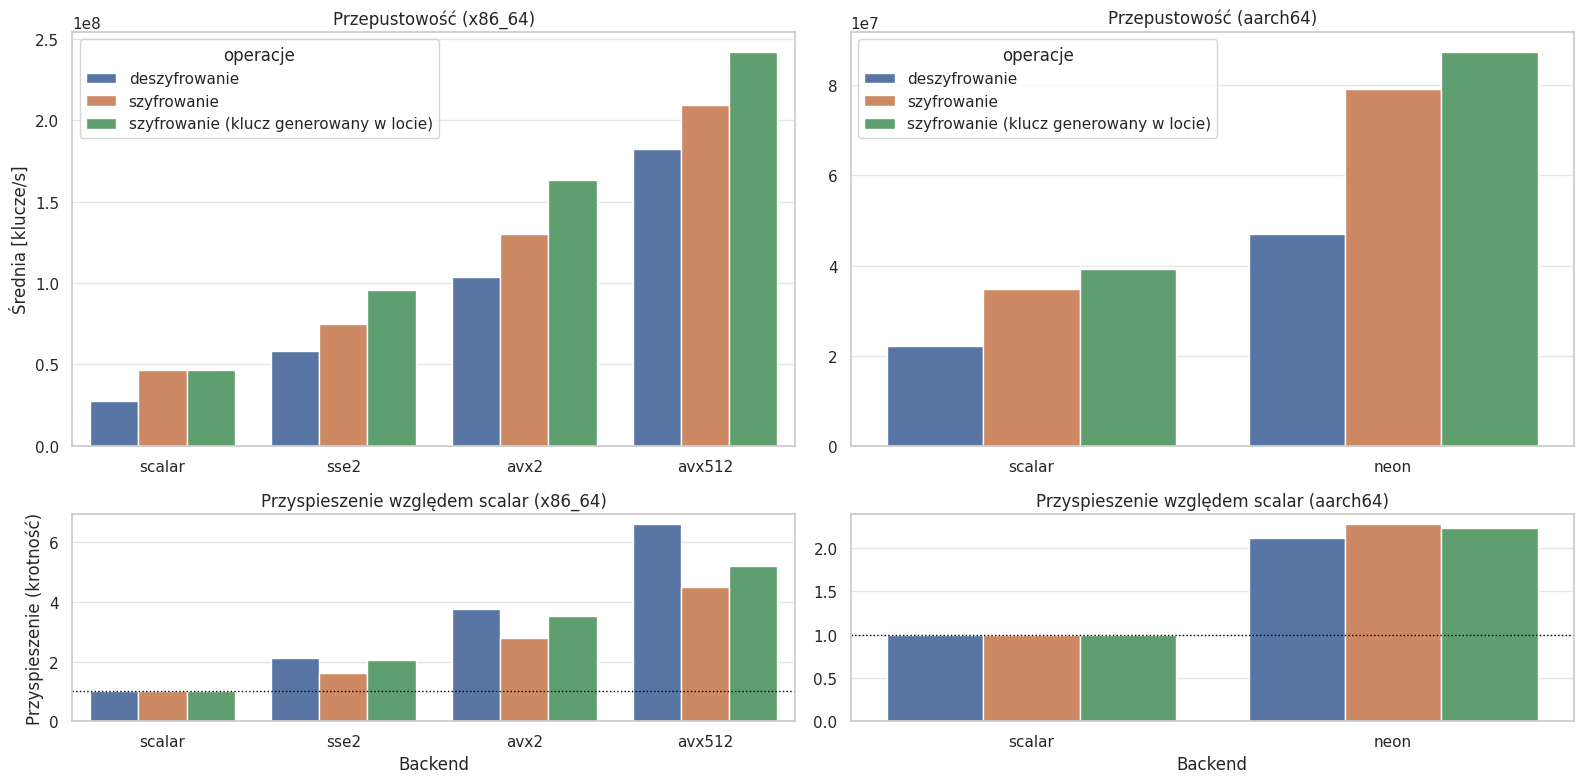

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})

for col, arch in enumerate(architecture_order):
    arch_data = engine_backend_function_mean[engine_backend_function_mean['architecture'] == arch]
    backend_order = backend_order_for_arch(engine_backend_function_mean, arch)
    ax1 = axes[0, col]
    ax2 = axes[1, col]

    sns.barplot(data=arch_data, x='backend', y='mean', hue='function',
                order=backend_order, hue_order=function_order, ax=ax1)
    ax1.set_title(f'Przepustowość ({arch})')
    ax1.set_ylabel('Średnia [klucze/s]' if col == 0 else '')
    ax1.set_xlabel('')
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, [function_labels.get(label, label) for label in labels], title='operacje')

    sns.barplot(data=arch_data, x='backend', y='speedup', hue='function',
                order=backend_order, hue_order=function_order, ax=ax2)
    ax2.axhline(y=1.0, color='black', linestyle='dotted', linewidth=1)
    ax2.set_title(f'Przyspieszenie względem scalar ({arch})')
    ax2.set_xlabel('Backend')
    ax2.set_ylabel('Przyspieszenie (krotność)' if col == 0 else '')
    if ax2.get_legend() is not None:
        ax2.get_legend().remove()

plt.tight_layout()
plt.show()

In [14]:
engine_version = mean[(mean['benchmark'] == 'engine')].copy()
engine_version.head()

,benchmark,backend,architecture,function,version,suffix,mean
0,engine,avx2,x86_64,decrypt,128_128,1.0,5.126751e+07
1,engine,avx2,x86_64,decrypt,128_128,2.0,5.135678e+07
2,engine,avx2,x86_64,decrypt,128_128,3.0,5.119120e+07
3,engine,avx2,x86_64,decrypt,128_192,1.0,5.076083e+07
4,engine,avx2,x86_64,decrypt,128_192,2.0,5.086562e+07


In [15]:
engine_version_backend_mean = engine_version.groupby(['architecture', 'backend', 'version'])['mean'].mean().reset_index()
scalar_version_mean = (
    engine_version_backend_mean[engine_version_backend_mean['backend'] == 'scalar'][['architecture', 'version', 'mean']]
    .rename(columns={'mean': 'scalar_mean'})
)
engine_version_backend_mean = engine_version_backend_mean.merge(
    scalar_version_mean,
    on=['architecture', 'version'],
    how='left'
)
engine_version_backend_mean['speedup'] = engine_version_backend_mean['mean'] / engine_version_backend_mean['scalar_mean']
engine_version_backend_mean

,architecture,backend,version,mean,scalar_mean,speedup
0,aarch64,neon,128_128,5.379912e+07,3.225179e+07,1.668097
1,aarch64,neon,128_192,4.854903e+07,3.213355e+07,1.510852
2,aarch64,neon,128_256,4.552767e+07,3.226470e+07,1.411067
3,aarch64,neon,32_64,1.937867e+08,3.436523e+07,5.639035
4,aarch64,neon,48_72,7.512760e+07,3.072067e+07,2.445507
5,aarch64,neon,48_96,7.144158e+07,2.945561e+07,2.425398
6,aarch64,neon,64_128,8.414684e+07,4.293721e+07,1.959765
7,aarch64,neon,64_96,8.835879e+07,4.422651e+07,1.997869
8,aarch64,neon,96_144,2.631767e+07,2.127437e+07,1.237060
9,aarch64,neon,96_96,2.517752e+07,2.064231e+07,1.219704


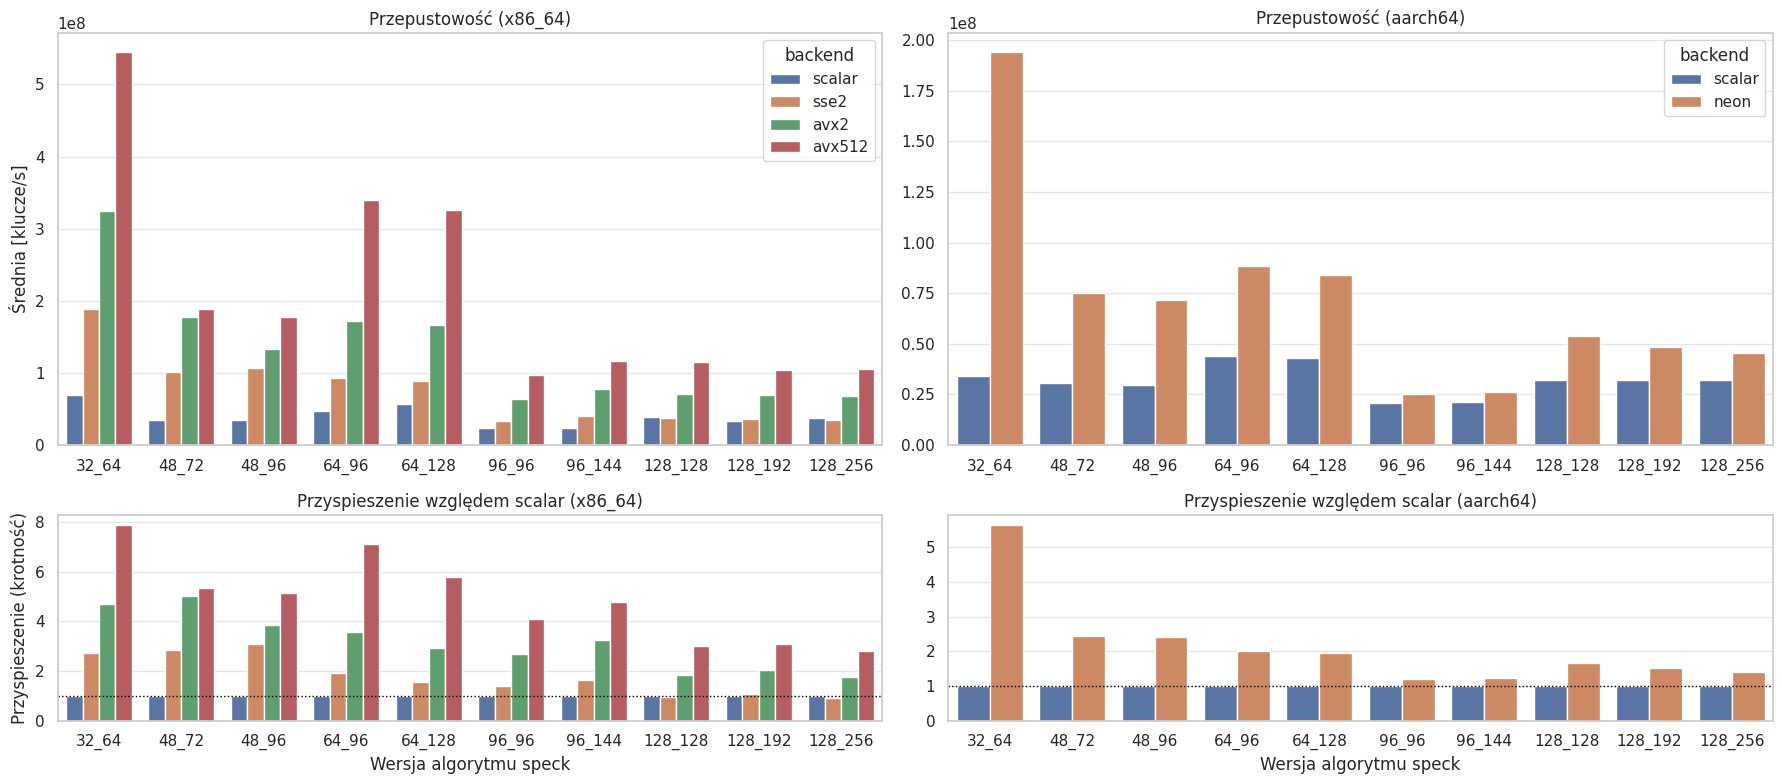

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8), gridspec_kw={'height_ratios': [2, 1]})

for col, arch in enumerate(architecture_order):
    arch_data = engine_version_backend_mean[engine_version_backend_mean['architecture'] == arch]
    backend_order = backend_order_for_arch(engine_version_backend_mean, arch)
    ax1 = axes[0, col]
    ax2 = axes[1, col]

    sns.barplot(data=arch_data, x='version', y='mean', hue='backend',
                order=version_order, hue_order=backend_order, ax=ax1)
    ax1.set_title(f'Przepustowość ({arch})')
    ax1.set_ylabel('Średnia [klucze/s]' if col == 0 else '')
    ax1.set_xlabel('')
    ax1.get_legend().set_title('backend')

    sns.barplot(data=arch_data, x='version', y='speedup', hue='backend',
                order=version_order, hue_order=backend_order, ax=ax2)
    ax2.axhline(y=1.0, color='black', linestyle='dotted', linewidth=1)
    ax2.set_title(f'Przyspieszenie względem scalar ({arch})')
    ax2.set_xlabel('Wersja algorytmu speck')
    ax2.set_ylabel('Przyspieszenie (krotność)' if col == 0 else '')
    if ax2.get_legend() is not None:
        ax2.get_legend().remove()

plt.tight_layout()
plt.show()

In [17]:
engine_speck = mean[(mean['function'] == 'encrypt_inflight')].copy()
engine_speck.head()

,benchmark,backend,architecture,function,version,suffix,mean
60,engine,avx2,x86_64,encrypt_inflight,128_128,1.0,9.401697e+07
61,engine,avx2,x86_64,encrypt_inflight,128_128,2.0,9.301042e+07
62,engine,avx2,x86_64,encrypt_inflight,128_128,3.0,9.524456e+07
63,engine,avx2,x86_64,encrypt_inflight,128_192,1.0,8.948344e+07
64,engine,avx2,x86_64,encrypt_inflight,128_192,2.0,8.961646e+07


In [18]:
engine_speck = mean[mean['function'] == 'encrypt_inflight'].copy()

engine = (
    engine_speck[engine_speck['benchmark'] == 'engine']
    .assign(suffix=lambda d: d['suffix'].astype('Int64').astype(str))
    .groupby(['architecture', 'backend', 'suffix'], as_index=False)['mean']
    .mean()
)

speck = (
    engine_speck[engine_speck['benchmark'] == 'speck']
    .groupby(['architecture', 'backend'], as_index=False)['mean']
    .mean()
    .rename(columns={'mean': 'speck_mean'})
)

cmp = engine.merge(speck, on=['architecture', 'backend'], how='left')
cmp['speedup_vs_speck'] = cmp['mean'] / cmp['speck_mean']

throughput_df = pd.concat([
    cmp.assign(series='engine s=' + cmp['suffix'])[['architecture', 'backend', 'mean', 'series']],
    speck.rename(columns={'speck_mean': 'mean'}).assign(series='speck')[['architecture', 'backend', 'mean', 'series']]
], ignore_index=True)

speed_df = pd.concat([
    cmp.assign(series='engine s=' + cmp['suffix'])[['architecture', 'backend', 'speedup_vs_speck', 'series']],
    speck.assign(speedup_vs_speck=1.0, series='speck')[['architecture', 'backend', 'speedup_vs_speck', 'series']]
], ignore_index=True)

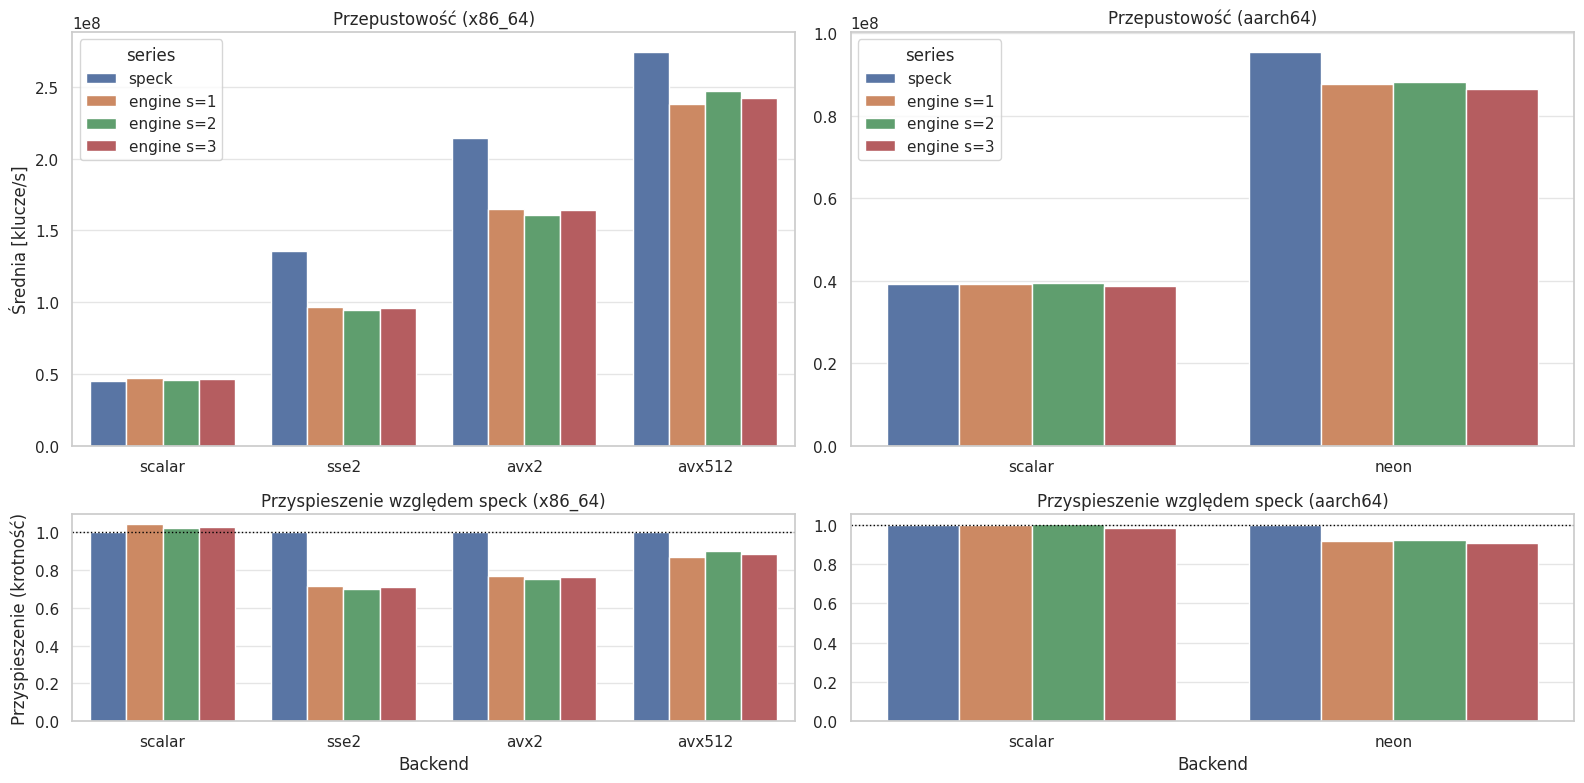

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})

for col, arch in enumerate(architecture_order):
    arch_throughput = throughput_df[throughput_df['architecture'] == arch]
    arch_speed = speed_df[speed_df['architecture'] == arch]
    backend_order = backend_order_for_arch(throughput_df, arch)
    ax1 = axes[0, col]
    ax2 = axes[1, col]

    sns.barplot(data=arch_throughput, x='backend', y='mean', hue='series',
                order=backend_order, hue_order=series_order, ax=ax1)
    ax1.set_title(f'Przepustowość ({arch})')
    ax1.set_ylabel('Średnia [klucze/s]' if col == 0 else '')
    ax1.set_xlabel('')

    sns.barplot(data=arch_speed, x='backend', y='speedup_vs_speck', hue='series',
                order=backend_order, hue_order=series_order, ax=ax2)
    ax2.axhline(1.0, color='black', linestyle='dotted', linewidth=1)
    ax2.set_title(f'Przyspieszenie względem speck ({arch})')
    ax2.set_xlabel('Backend')
    ax2.set_ylabel('Przyspieszenie (krotność)' if col == 0 else '')
    if ax2.get_legend() is not None:
        ax2.get_legend().remove()

plt.tight_layout()
plt.show()